In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib_venn import venn2

In [2]:
def calculate_and_plot_venn(
    df: pd.DataFrame, col_a: str, col_b: str, label_a: str , label_b: str , output: str
) -> dict:
    mask_a = df[col_a].astype(bool)
    mask_b = df[col_b].astype(bool)

    # Calculate metrics using bitwise logical operators
    a_not_b = int((mask_a & ~mask_b).sum())
    b_not_a = int((~mask_a & mask_b).sum())
    a_and_b = int((mask_a & mask_b).sum())

    # Print the metrics directly to the terminal
    print(f"--- Venn Metrics for Boolean Columns '{col_a}' vs '{col_b}' ---")
    print(f"True in {label_a} only (Ab):  {a_not_b}")
    print(f"True in both {label_a} & {label_b} (AB):  {a_and_b}")
    print(f"True in {label_b} only (aB):  {b_not_a}")
    print("-" * 55)

    # Generate the plot
    fig, ax = plt.subplots(figsize=(3, 3))

    # subsets=(Ab, aB, AB)
    venn2(subsets=(a_not_b, b_not_a, a_and_b), set_labels=(label_a, label_b), ax=ax)
   
    fig.savefig(output, dpi=300)



TSP:
All:
--- Venn Metrics for Boolean Columns 'detected:fraction:POC' vs 'detected:fraction:WSOC' ---
True in POC only (Ab):  4957
True in both POC & WSOC (AB):  2171
True in WSOC only (aB):  2341
-------------------------------------------------------
--- Venn Metrics for Boolean Columns 'detected:day_type:weekend' vs 'detected:day_type:weekday' ---
True in Weekend only (Ab):  4620
True in both Weekend & Weekday (AB):  3405
True in Weekday only (aB):  1444
-------------------------------------------------------
With MS2:
--- Venn Metrics for Boolean Columns 'detected:fraction:POC' vs 'detected:fraction:WSOC' ---
True in POC only (Ab):  237
True in both POC & WSOC (AB):  505
True in WSOC only (aB):  75
-------------------------------------------------------
--- Venn Metrics for Boolean Columns 'detected:day_type:weekend' vs 'detected:day_type:weekday' ---
True in Weekend only (Ab):  84
True in both Weekend & Weekday (AB):  685
True in Weekday only (aB):  48
---------------------------

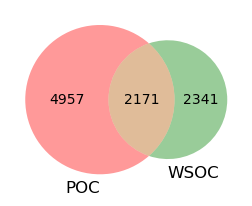

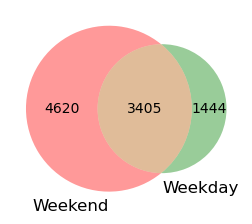

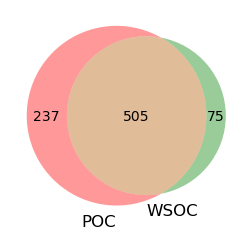

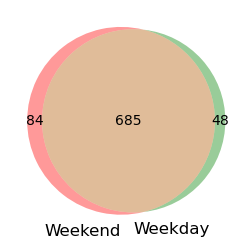

In [3]:
print('TSP:')
print('All:')

da_tsp_df=pd.read_csv('../results/easvolee_tsp_pos/analysis/features/da.csv', low_memory=False)


calculate_and_plot_venn(da_tsp_df, 'detected:fraction:POC','detected:fraction:WSOC', "POC",'WSOC','../additional_figures/venn_tsp_fraction.png')
calculate_and_plot_venn(da_tsp_df, 'detected:day_type:weekend','detected:day_type:weekday', "Weekend",'Weekday','../additional_figures/venn_tsp_daytype.png')

da_tsp_ms2_df=da_tsp_df[da_tsp_df['has_ms2']]

print('With MS2:')

calculate_and_plot_venn(da_tsp_ms2_df, 'detected:fraction:POC','detected:fraction:WSOC', "POC",'WSOC','../additional_figures/venn_tsp_fraction_blank.png')
calculate_and_plot_venn(da_tsp_ms2_df, 'detected:day_type:weekend','detected:day_type:weekday', "Weekend",'Weekday','../additional_figures/venn_tsp_daytype_blank.png')



UFP:
--- Venn Metrics for Boolean Columns 'detected:fraction:POC' vs 'detected:fraction:WSOC' ---
True in POC only (Ab):  5005
True in both POC & WSOC (AB):  1806
True in WSOC only (aB):  2595
-------------------------------------------------------
--- Venn Metrics for Boolean Columns 'detected:day_type:weekend' vs 'detected:day_type:weekday' ---
True in Weekend only (Ab):  2355
True in both Weekend & Weekday (AB):  4454
True in Weekday only (aB):  2597
-------------------------------------------------------
UFP:
--- Venn Metrics for Boolean Columns 'detected:fraction:POC' vs 'detected:fraction:WSOC' ---
True in POC only (Ab):  224
True in both POC & WSOC (AB):  357
True in WSOC only (aB):  90
-------------------------------------------------------
--- Venn Metrics for Boolean Columns 'detected:day_type:weekend' vs 'detected:day_type:weekday' ---
True in Weekend only (Ab):  32
True in both Weekend & Weekday (AB):  558
True in Weekday only (aB):  81
-------------------------------------

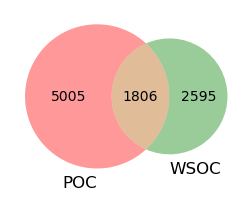

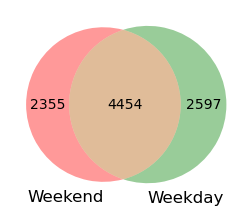

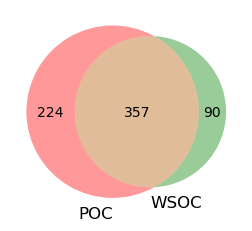

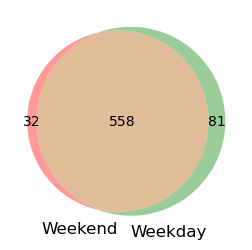

In [4]:
print('UFP:')


da_ufp_df=pd.read_csv('../results/easvolee_ufp_pos/analysis/features/da.csv', low_memory=False)
da_tsp_df=da_ufp_df[da_ufp_df['has_ms2']]

calculate_and_plot_venn(da_ufp_df, 'detected:fraction:POC','detected:fraction:WSOC', "POC",'WSOC','../additional_figures/venn_ufp_fraction.png')


calculate_and_plot_venn(da_ufp_df, 'detected:day_type:weekend','detected:day_type:weekday', "Weekend",'Weekday','../additional_figures/venn_ufp_daytype.png')

print('UFP:')

da_ufp_df=pd.read_csv('../results/easvolee_ufp_pos/analysis/features/da.csv', low_memory=False)
da_ufp_df=da_ufp_df[da_ufp_df['has_ms2']]

calculate_and_plot_venn(da_ufp_df, 'detected:fraction:POC','detected:fraction:WSOC', "POC",'WSOC','../additional_figures/venn_ufp_fraction_blank.png')
calculate_and_plot_venn(da_ufp_df, 'detected:day_type:weekend','detected:day_type:weekday', "Weekend",'Weekday','../additional_figures/venn_ufp_daytype_blank.png')

In [5]:
import seaborn as sns
import numpy as np

def plot_filtered_counts(
    a_df:  pd.DataFrame,
    b_df: pd.DataFrame,
    a_label: str,
    b_label: str,
    target_col: str,
    prob_col: str,
    threshold: float ,
    min_count: int,
    output: str
):
    filtered_a_df = a_df[a_df[prob_col] > threshold]
    counts_a = filtered_a_df[target_col].value_counts()
    counts_a = counts_a[counts_a > min_count]

    filtered_b_df = b_df[b_df[prob_col] > threshold]
    counts_b = filtered_b_df[target_col].value_counts()
    counts_b = counts_b[counts_b > min_count]

    width = 0.4
    all_labels = sorted(
        set(counts_a.index) | set(counts_b.index),
        key=lambda l: -(counts_a.get(l, 0) + 1) / (counts_b.get(l, 0) + 1)
    )
    x = np.arange(len(all_labels))

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.bar(x - width/2, [counts_a.get(l, 0) for l in all_labels], width=width, label=a_label)
    ax.bar(x + width/2, [counts_b.get(l, 0) for l in all_labels], width=width, label=b_label)
    ax.set_xticks(x)
    ax.set_xticklabels(all_labels, rotation=45, ha="right")
    ax.set_xlabel(target_col, fontsize=11)
    ax.set_ylabel("Count", fontsize=11)
    ax.legend()
    fig.tight_layout()
    fig.savefig(output,dpi=300)

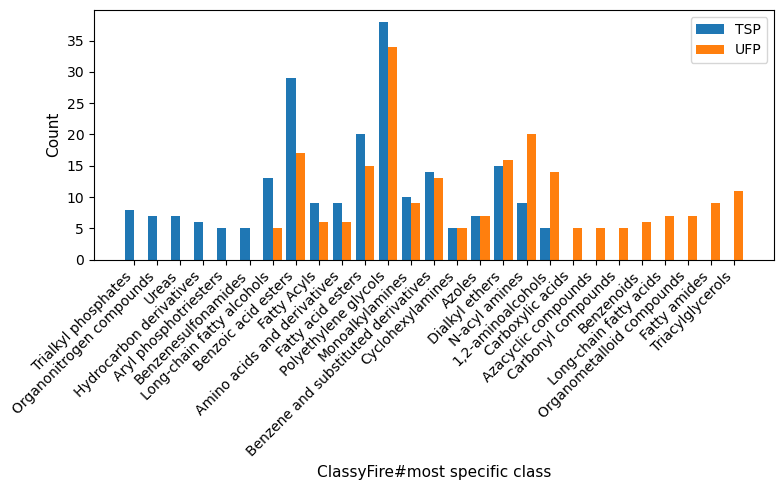

In [6]:
canopus_classes_tsp=pd.read_csv('../results/easvolee_tsp_pos/sirius/summaries/canopus_structure_summary.tsv',sep='\t')
canopus_classes_ufp=pd.read_csv('../results/easvolee_ufp_pos/sirius/summaries/canopus_structure_summary.tsv',sep='\t')
plot_filtered_counts(canopus_classes_tsp, canopus_classes_ufp, 'TSP','UFP', 'ClassyFire#most specific class','ClassyFire#most specific class Probability',0.7, 4,'../additional_figures/canopus_tsp_ufp.png')

In [7]:
da_df = pd.read_csv('../results/easvolee_tsp_pos/analysis/features/da.csv')

def plot_filtered_counts_da_condition(
    df: pd.DataFrame,
    a_col: str,
    b_col: str,
    a_label: str,
    b_label: str,
    target_col: str,
    prob_col: str,
    threshold: float,
    min_count: int,
    output: str):
    filtered_A = da_df[da_df[a_col] & ~da_df[b_col]]
    filtered_B = da_df[da_df[b_col] & ~da_df[a_col]]

    canopus_classes_A = df[df["mappingFeatureId"].isin(filtered_A['id'])]
    canopus_classes_B = df[df["mappingFeatureId"].isin(filtered_B['id'])]

    plot_filtered_counts(canopus_classes_A, canopus_classes_B, a_label, b_label, target_col, prob_col, threshold, min_count, output)



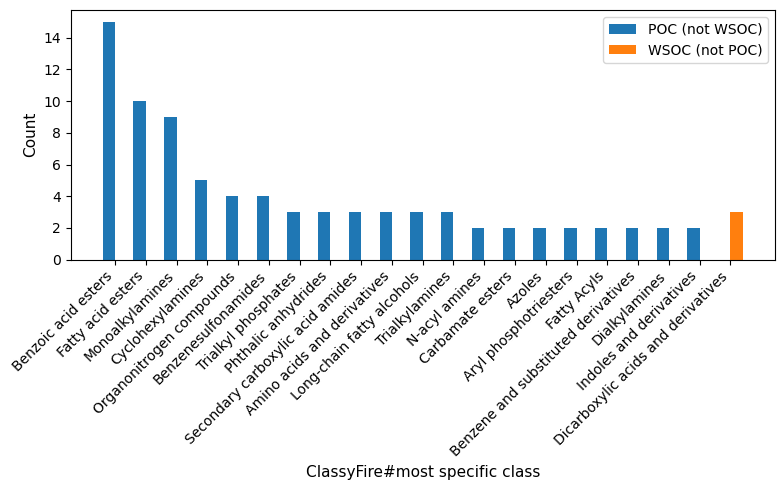

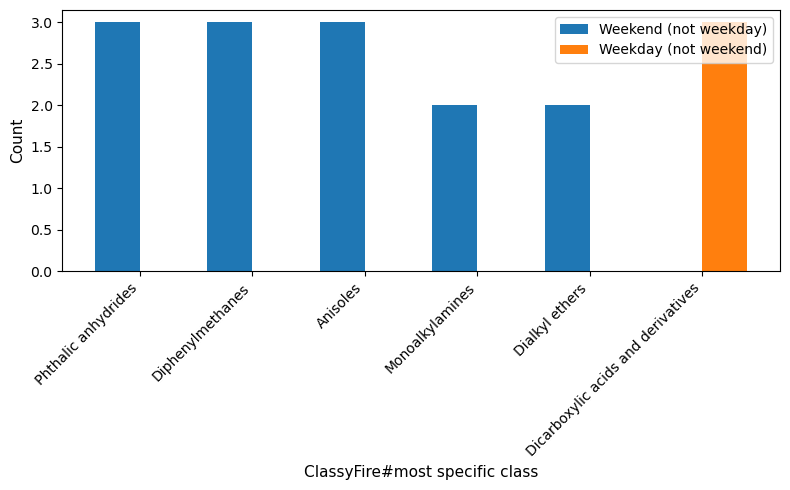

In [8]:
plot_filtered_counts_da_condition(canopus_classes_tsp, 'detected:fraction:POC', 'detected:fraction:WSOC', 'POC (not WSOC)','WSOC (not POC)', 'ClassyFire#most specific class','ClassyFire#most specific class Probability',0.7,1, '../additional_figures/canopus_tsp_fraction.png')
plot_filtered_counts_da_condition(canopus_classes_tsp, 'detected:day_type:weekend', 'detected:day_type:weekday', 'Weekend (not weekday)','Weekday (not weekend)', 'ClassyFire#most specific class','ClassyFire#most specific class Probability',0.7,1, '../additional_figures/canopus_tsp_daytype.png')

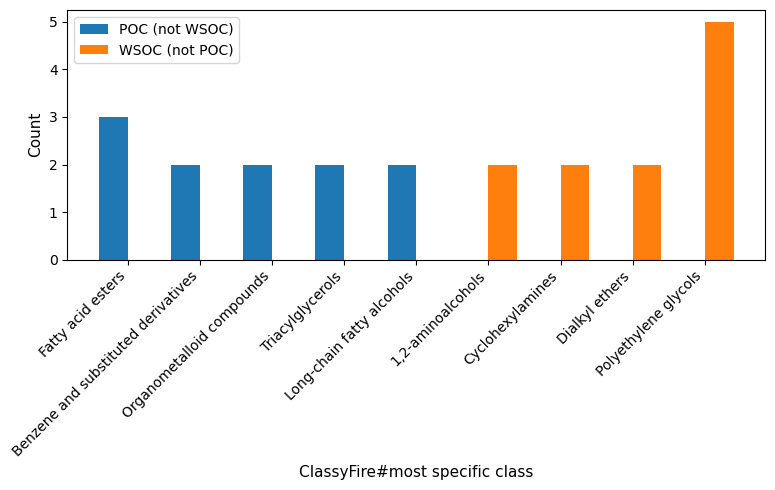

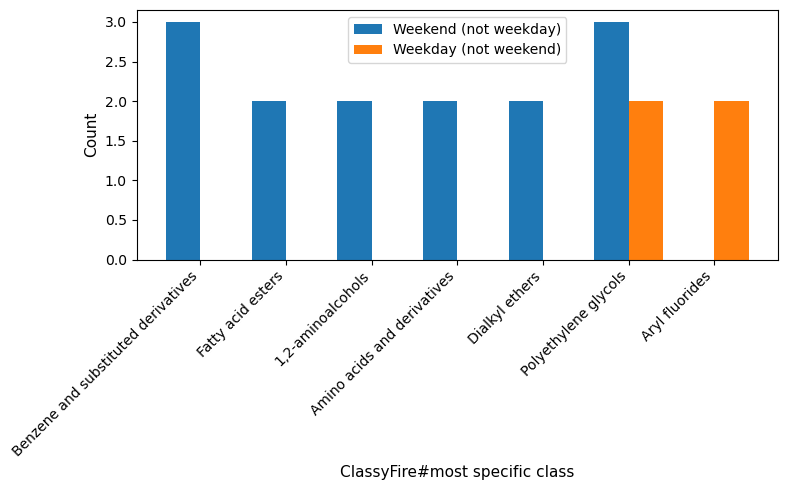

In [9]:
plot_filtered_counts_da_condition(canopus_classes_ufp, 'detected:fraction:POC', 'detected:fraction:WSOC', 'POC (not WSOC)','WSOC (not POC)', 'ClassyFire#most specific class','ClassyFire#most specific class Probability',0.7, 1,'../additional_figures/canopus_ufp_fraction.png')
plot_filtered_counts_da_condition(canopus_classes_ufp, 'detected:day_type:weekend', 'detected:day_type:weekday', 'Weekend (not weekday)','Weekday (not weekend)', 'ClassyFire#most specific class','ClassyFire#most specific class Probability',0.7, 1,'../additional_figures/canopus_ufp_daytype.png')

In [11]:
da_tsp_df = pd.read_csv('../results/easvolee_tsp_pos/analysis/features/da.csv')
query_neighbors_tsp_df = pd.read_csv('../results/easvolee_tsp_pos/analysis/bioactivity/query_neighbors.csv')

merged_da_qn_tsp_df = pd.merge(query_neighbors_tsp_df,da_tsp_df, on='id')
merged_da_qn_tsp_df[['compound_name', 'annotation_type','score','query_min_distance', 'log2FC:fraction:POC_vs_WSOC','welch_q:fraction:POC_vs_WSOC','log2FC:day_type:weekday_vs_weekend','welch_q:day_type:weekday_vs_weekend']]

,compound_name,annotation_type,score,query_min_distance,log2FC:fraction:POC_vs_WSOC,welch_q:fraction:POC_vs_WSOC,log2FC:day_type:weekday_vs_weekend,welch_q:day_type:weekday_vs_weekend
0,Campathecin,spectral_match,0.847457,37.217371,8.741381,0.000009,0.028522,0.968809
1,Indigo J,spectral_match,0.802074,42.724512,10.366719,0.000695,4.175436,0.013591
2,2-Phenylbenzothiazole,structure_db_match,0.845000,48.420276,2.880664,0.000090,-1.129867,0.157157
3,benzothiazolol,spectral_match,0.952819,61.645049,-0.127222,0.322706,-0.241981,0.155336


In [12]:
da_ufp_df = pd.read_csv('../results/easvolee_ufp_pos/analysis/features/da.csv')
query_neighbors_ufp_df = pd.read_csv('../results/easvolee_ufp_pos/analysis/bioactivity/query_neighbors.csv')

merged_da_qn_ufp_df = pd.merge(query_neighbors_ufp_df, da_ufp_df, on='id')
merged_da_qn_ufp_df[['compound_name',  'annotation_type','score','query_min_distance',  'log2FC:fraction:POC_vs_WSOC','welch_q:fraction:POC_vs_WSOC','log2FC:day_type:weekday_vs_weekend','welch_q:day_type:weekday_vs_weekend']]

,compound_name,annotation_type,score,query_min_distance,log2FC:fraction:POC_vs_WSOC,welch_q:fraction:POC_vs_WSOC,log2FC:day_type:weekday_vs_weekend,welch_q:day_type:weekday_vs_weekend
0,2-Phenylbenzothiazole,structure_db_match,0.852000,24.778342,2.968132,0.000081,-1.251986,0.332955
1,"1H,3H-naphtho[2,3-c]furan-1,3-dione",denovo,-0.162000,29.681338,1.204625,0.005317,-0.824266,0.366502
2,5-Methylbenzimidazole,denovo,-0.434000,34.865933,1.889412,0.000738,-1.205460,0.324397
3,Indigo J,spectral_match,0.803781,36.871136,7.023139,0.024833,-2.281971,0.397489
4,9-Fluorenone-2-carboxylic acid,denovo,-1.717000,42.074251,2.094915,0.000423,-1.057184,0.346614
5,"N-Phenyl-1,3-benzothiazol-2-amine",denovo,-0.325000,44.957974,3.870358,0.000169,-1.718254,0.313204
6,Benzoanthrone,spectral_match,0.890044,48.428577,inf,0.000010,-1.314667,0.349565
7,benzothiazolyl-cyclohexyl-amine,spectral_match,0.973851,49.732345,2.557264,0.000559,-1.473315,0.317009
